In [60]:
#Let's remake the polynomial fit just so I can tell if the 20% offset makes sense.
#Just doing it on one strip would be cool and good TM
#Choosing my favorite strip...
#L0R1M5S3 is relatively inoffensive strip!

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

#p0a p1a p2a is pol2 fit between 0-190 ADC ch 
#p0b p1b p2b p3b is pol3 fit between 190-500 ADC ch 
#p0c p1c p2c p3c is pol3 fit between 500-900 ADC ch 
#p0d p1d p2d p3d is pol3 fit between 900-1600 ADC ch
#Layer Row Module Channel p0a p1a p2a p0b p1b p2b p3b p0c p1c p2c p3c p0d p1d p2d p3d   

#271225
#0,1,5,3,-0.2,1.058,0.0014,-407.53,5.99,-0.0187,0.0000281,-1997.22,23.25,-0.0676,0.0000697,18183.7,-94.98,0.122,-0.0000226

#241125
#0,1,5,3,0.00,1.057,0.0008,-246.52,3.96,-0.0108,0.0000163,-11345.96,65.46,-0.1256,0.0000887,40000.08,-144.49,0.151,-0.0000300


#Data below is 271225
x = np.arange(0, 1600)
p0_190 = Polynomial([-0.2,1.058,0.0014])
p190_500 = Polynomial([-407.53,5.99,-0.0187,0.0000281])
p500_900 = Polynomial([-1997.22,23.25,-0.0676,0.0000697])
p900_1600 = Polynomial([18183.7,-94.98,0.122,-0.0000226])

#ADC to keV
def tf_fit(ADC): 
    if(ADC < 190 and ADC > 0):
        return p0_190(ADC)
    if(ADC > 190 and ADC < 500):
        return p190_500(ADC)
    if(ADC > 500 and ADC < 900):
        return p500_900(ADC)
    if(ADC > 900 and ADC < 1600):
        return p900_1600(ADC)

print(tf_fit(10))
print(p0_190(10))

print(tf_fit(400))
print(p190_500(400))

print(tf_fit(1000))
print(p900_1600(1000))

y11 = [tf_fit(xval) for xval in x]

#plt.plot(x,y)

10.520000000000001
10.520000000000001
794.8699999999999
794.8699999999999
22603.69999999999
22603.69999999999


In [61]:
#Data below is 241125, GROUND
#y = [p0_190(xval) for xval in x]
p0_190_2 = Polynomial([0.00,1.057,0.0008])
p190_500_2 = Polynomial([-246.52,3.96,-0.0108,0.0000163])
p500_900_2 = Polynomial([-11345.96,65.46,-0.1256,0.0000887])
p900_1600_2 = Polynomial([40000.08,-144.49,0.151,-0.0000300])

def tf_fit_2(ADC): 
    if(ADC < 190 and ADC > 0):
        return p0_190_2(ADC)
    if(ADC > 190 and ADC < 500):
        return p190_500_2(ADC)
    if(ADC > 500 and ADC < 900):
        return p500_900_2(ADC)
    if(ADC > 900 and ADC < 1600):
        return p900_1600_2(ADC)

y12 = [tf_fit_2(xval) for xval in x]

#So redefining the poly fits DOES change this
print(tf_fit(1000))

22603.69999999999


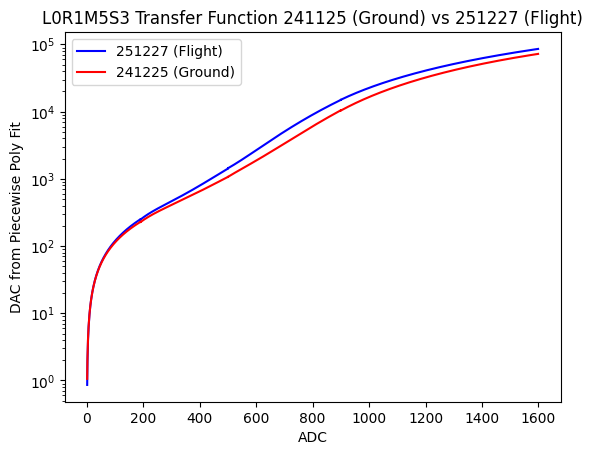

In [132]:
plt.plot(x[1:],y11[1:], label='251227 (Flight)', color='blue') # First plot
plt.plot(x[1:],y12[1:], label='241225 (Ground)', color='red') 
#plt.xlim(100, 1600) 
#plt.ylim(100, 20e4) 
plt.yscale('log')
plt.title('L0R1M5S3 Transfer Function 241125 (Ground) vs 251227 (Flight)')
plt.xlabel("ADC")
plt.ylabel("DAC from Piecewise Poly Fit")
plt.legend() 
plt.show()

1.051890941072999
0.8594000000000002


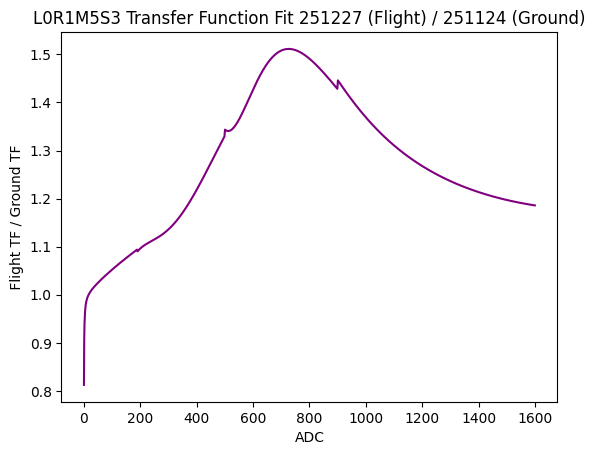

In [129]:
print(y11[100]/y12[100])
print(y11[1])
perc = np.zeros(len(y11))

for i in range(len(y11)):
    if(y11[i] is not None and y12[i] is not None):
        #print(y11[i]/y12[i])
        perc[i] = y11[i]/y12[i]
mask = perc > 0

plt.plot(x[mask],perc[mask], label='Nov/24 / Dec/27 TFs', color='purple')
plt.title('L0R1M5S3 Transfer Function Fit 251227 (Flight) / 251124 (Ground)')
plt.xlabel("ADC")
plt.ylabel(" Flight TF / Ground TF ")
plt.show()

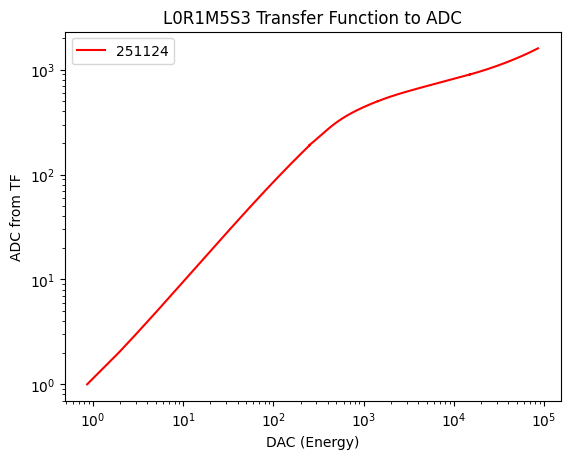

In [137]:
plt.plot(y11,x, label='251124', color='red') # First plot
#plt.plot(y12,x, label='251227', color='blue') 
#plt.yscale('log')

plt.title('L0R1M5S3 Transfer Function to ADC')
plt.xlabel("DAC (Energy)")
plt.ylabel("ADC from TF")

plt.xscale('log')
plt.yscale('log')
plt.legend() 
plt.show()